# MISSING VALUES OF CATAGORICAL AND NUMERICAL VALUES

## Random Imputation 

In [2]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


In [4]:
# upload titanic dataset only use age, fare, survived
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv', usecols=['Survived', 'Age', 'Fare'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [5]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [6]:
x = df.drop(columns='Survived')
y = df['Survived']

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [8]:
x_train['age_imputed'] = x_train['Age']
x_test['age_imputed'] = x_test['Age']

In [9]:
x_train.head()

,Age,Fare,age_imputed
331,45.5,28.5000,45.5
733,23.0,13.0000,23.0
382,32.0,7.9250,32.0
704,26.0,7.8542,26.0
813,6.0,31.2750,6.0


In [10]:
x_test.head()

,Age,Fare,age_imputed
709,NaN,15.2458,NaN
439,31.0,10.5000,31.0
840,20.0,7.9250,20.0
720,6.0,33.0000,6.0
39,14.0,11.2417,14.0


In [26]:
x_train['age_imputed'] = x_train['age_imputed'].fillna(pd.Series(x_train['Age'].dropna().sample(x_train['Age'].isnull().sum()).values))
x_test['age_imputed'] = x_test['age_imputed'].fillna(pd.Series(x_test['Age'].dropna().sample(x_test['Age'].isnull().sum()).values))

In [27]:
x_train['Age'].dropna().sample(x_train['Age'].isnull().sum()).values

array([47.  , 18.  , 39.  , 36.  , 47.  , 62.  ,  7.  , 20.  , 35.  ,
        7.  , 22.  , 22.  , 44.  , 21.  , 33.  , 39.  , 38.  ,  0.67,
       16.  , 63.  , 33.  , 23.  , 28.  , 30.  , 48.  ,  2.  , 18.  ,
       36.  , 45.  , 26.  , 19.  , 21.  , 56.  , 24.  , 26.  , 22.  ,
       48.  , 15.  , 18.  , 28.5 , 34.  ,  9.  , 29.  , 38.  , 24.  ,
       26.  , 22.  , 23.  , 17.  , 28.  , 17.  , 22.  , 25.  , 24.  ,
       52.  , 32.  , 21.  , 11.  , 34.  , 35.  , 42.  , 38.  , 29.  ,
        8.  , 25.  , 32.  ,  3.  , 50.  , 51.  , 24.5 , 19.  , 41.  ,
       19.  , 33.  , 35.  , 39.  , 24.  , 24.  , 28.  ,  1.  , 29.  ,
       19.  , 36.  , 21.  , 45.  , 32.  , 47.  , 32.  , 28.  , 52.  ,
        4.  , 53.  ,  8.  , 22.  , 29.  , 35.  , 22.  , 45.5 , 20.  ,
       17.  , 16.  , 51.  , 28.  , 28.  , 58.  , 24.  , 31.  , 43.  ,
       23.  , 42.  , 25.  , 29.  , 16.  , 29.  , 28.  , 27.  , 36.  ,
       54.  , 19.  ,  5.  , 29.  ,  3.  , 22.  , 28.  , 20.  , 25.  ,
       36.  , 32.  ,

In [28]:
x_train

,Age,Fare,age_imputed
331,45.5,28.5000,45.5
733,23.0,13.0000,23.0
382,32.0,7.9250,32.0
704,26.0,7.8542,26.0
813,6.0,31.2750,6.0
...,...,...,...
106,21.0,7.6500,21.0
270,NaN,31.0000,25.0
860,41.0,14.1083,41.0
435,14.0,120.0000,14.0


AttributeError: Rectangle.set() got an unexpected keyword argument 'hist'

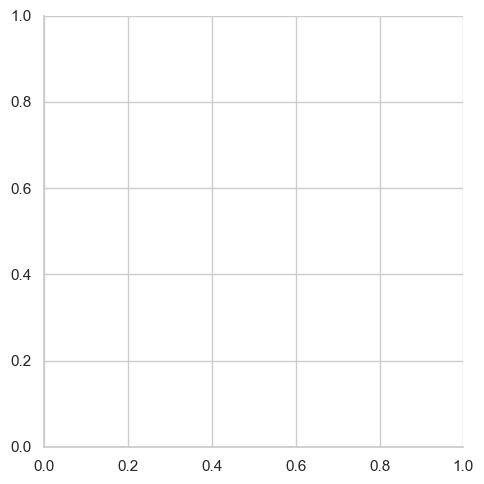

In [ ]:
sns.displot(x_train['Age'], label='Original', hist=False)
sns.displot(x_train['age_imputed'], label='imputed', hist=False)